# ArtStyle Predictor -- Model Training

Pipeline:
1. Data cleaning (corrupt/duplicate/tiny-image checks + class balance report)
2. Transforms & class-weighted loaders (fixes the imbalance the previous version ignored)
3. **Algorithm comparison** -- EfficientNet-B0 vs ResNet18 vs MobileNetV3-Small, same data, same budget
4. Full training of the best-performing architecture, with a single unambiguous checkpoint
5. Test-set evaluation with a confusion matrix (so misclassification patterns are visible, not just an accuracy number)
6. Saving `class_names.json` and `model_config.json` alongside the weights, so the Streamlit app never has to hardcode/guess the class order or architecture again

Run `data_preparation.py` first if `dataset/train`, `dataset/validation`, `dataset/test` don't exist yet -- see the README for the command.


In [1]:
import json
import time
import hashlib
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import timm
from PIL import Image, UnidentifiedImageError
from tqdm.notebook import tqdm

# Resolve the project root regardless of where Jupyter's working directory
# happens to be. VS Code / Jupyter typically start the kernel in the
# notebook's own folder (notebook/), not the project root where
# dataset/, data/, and artifacts/ actually live -- so a bare Path("dataset")
# silently resolves to notebook/dataset and finds nothing.
def find_project_root(start: Path) -> Path:
    for candidate in [start, start.parent, start.parent.parent]:
        if (candidate / "dataset").exists() or (candidate / "data").exists():
            return candidate
    return start  # fall back; you may need to set this manually below

PROJECT_ROOT = find_project_root(Path.cwd())
print(f"Project root resolved to: {PROJECT_ROOT.resolve()}")
# If that's wrong, set it explicitly instead, e.g.:
# PROJECT_ROOT = Path(r"D:\D drive\Project\art_style_classifier")

DATA_DIR = PROJECT_ROOT / "dataset"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Project root resolved to: D:\D drive\Project\art_style_classifier
Device: cpu


## 1. Data cleaning

Even after `data_preparation.py` has organized images into `dataset/<split>/<style>/`,
this pass re-checks the actual files that will be loaded by `ImageFolder`:

- drops any file that can't be opened/decoded (corrupt downloads, truncated JPEGs)
- drops exact-duplicate files (same content hash) *within* a class folder
- flags images below a minimum resolution (too small to carry useful texture/brushwork detail)
- reports the resulting per-class counts, so class imbalance is visible before training starts,
  not discovered afterwards in a confusing per-class accuracy table


In [2]:
MIN_SIDE_PX = 64  # images smaller than this on either side are dropped

def file_hash(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()


def clean_split(split_dir: Path):
    """Walk one split (train/validation/test), removing bad files in place
    and returning a per-class count + a list of problems found."""
    removed = {"corrupt": [], "duplicate": [], "too_small": []}
    counts = Counter()

    for class_dir in sorted(p for p in split_dir.iterdir() if p.is_dir()):
        seen_hashes = set()
        for img_path in sorted(class_dir.glob("*")):
            if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
                continue
            try:
                with Image.open(img_path) as im:
                    im.verify()
                with Image.open(img_path) as im:
                    im = im.convert("RGB")
                    w, h = im.size
            except (UnidentifiedImageError, OSError):
                removed["corrupt"].append(str(img_path))
                img_path.unlink()
                continue

            if min(w, h) < MIN_SIDE_PX:
                removed["too_small"].append(str(img_path))
                img_path.unlink()
                continue

            h_hash = file_hash(img_path)
            if h_hash in seen_hashes:
                removed["duplicate"].append(str(img_path))
                img_path.unlink()
                continue
            seen_hashes.add(h_hash)

            counts[class_dir.name] += 1

    return counts, removed


all_counts = {}
all_removed = {"corrupt": 0, "duplicate": 0, "too_small": 0}

for split in ["train", "validation", "test"]:
    split_dir = DATA_DIR / split
    if not split_dir.exists():
        print(f"[WARNING] {split_dir} does not exist yet -- run data_preparation.py first.")
        continue
    counts, removed = clean_split(split_dir)
    all_counts[split] = counts
    for k in all_removed:
        all_removed[k] += len(removed[k])
    print(f"{split}: {sum(counts.values())} valid images across {len(counts)} classes")

print("\nRemoved during cleaning:", all_removed)


train: 3097 valid images across 12 classes
validation: 657 valid images across 12 classes
test: 686 valid images across 12 classes

Removed during cleaning: {'corrupt': 0, 'duplicate': 0, 'too_small': 0}


,train,validation,test
Baroque,231,49,52
Cubism,84,18,18
Expressionism,245,52,55
Impressionism,512,108,114
Pop Art,84,18,18
Post-Impressionism,202,43,46
Primitivism,217,46,47
Renaissance,753,160,165
Romanticism,151,31,35
Suprematism,84,18,18


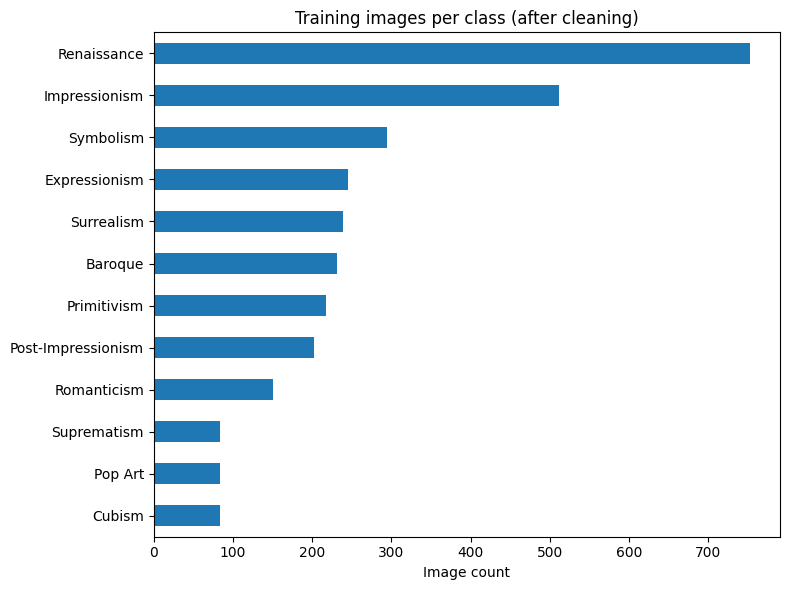

In [3]:
# Class balance report -- do this BEFORE training so imbalance is a known
# quantity, not a surprise buried in a per-class accuracy table afterwards.
balance_df = pd.DataFrame(all_counts).fillna(0).astype(int)
display(balance_df)

balance_df["train"].sort_values().plot(kind="barh", figsize=(8, 6), title="Training images per class (after cleaning)")
plt.xlabel("Image count")
plt.tight_layout()
plt.show()


## 2. Transforms & class-weighted loaders

Two real fixes from the previous version:

- **Resolution 128 -> 224.** EfficientNet-B0 (and the comparison architectures below) are
  pretrained at 224x224. Downscaling to 128 throws away exactly the brushwork/texture
  detail that distinguishes visually similar movements (e.g. Post-Impressionism vs.
  Impressionism).
- **Class weights.** The old training loop used plain `CrossEntropyLoss()` while some
  classes (Cubism, Suprematism) have a fraction of the images of others. Weights are
  computed as inverse class frequency so the loss doesn't get dominated by the big classes.


In [4]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = ImageFolder(DATA_DIR / "train", transform=train_transform)
val_dataset = ImageFolder(DATA_DIR / "validation", transform=eval_transform)
test_dataset = ImageFolder(DATA_DIR / "test", transform=eval_transform)

class_names = train_dataset.classes  # alphabetical order, from ImageFolder itself
num_classes = len(class_names)
print("Classes (from ImageFolder, this is the ground truth order):")
print(class_names)

# Inverse-frequency class weights, computed from the TRAIN split only
train_counts = Counter(train_dataset.targets)
total = sum(train_counts.values())
class_weights = torch.tensor(
    [total / (num_classes * train_counts[i]) for i in range(num_classes)],
    dtype=torch.float32,
).to(device)
print("\nClass weights (higher = rarer class, weighted up in the loss):")
for name, w in zip(class_names, class_weights.tolist()):
    print(f"  {name:20s} {w:.3f}")

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


Classes (from ImageFolder, this is the ground truth order):
['Baroque', 'Cubism', 'Expressionism', 'Impressionism', 'Pop Art', 'Post-Impressionism', 'Primitivism', 'Renaissance', 'Romanticism', 'Suprematism', 'Surrealism', 'Symbolism']

Class weights (higher = rarer class, weighted up in the loss):
  Baroque              1.117
  Cubism               3.072
  Expressionism        1.053
  Impressionism        0.504
  Pop Art              3.072
  Post-Impressionism   1.278
  Primitivism          1.189
  Renaissance          0.343
  Romanticism          1.709
  Suprematism          3.072
  Surrealism           1.080
  Symbolism            0.875


## 3. Model definition

Using `timm.create_model(arch, pretrained=True, num_classes=num_classes)` directly instead
of manually slicing off the last child of the backbone (`nn.Sequential(*list(model.children())[:-1])`).
The manual-slicing approach from the original notebook is architecture-specific and silently
breaks (wrong output shape, or wrong layer removed) if you ever swap in a different backbone --
which is exactly what the comparison step below needs to do safely.


In [5]:
def build_model(arch_name: str, num_classes: int) -> nn.Module:
    return timm.create_model(arch_name, pretrained=True, num_classes=num_classes)


## 4. Algorithm comparison

Same data, same class weights, same number of short training runs (5 epochs each -- enough
to see which architecture is learning faster/better on this data, not a final training run).
Compared on **macro-F1** rather than plain accuracy, since macro-F1 doesn't let the big
classes hide poor performance on the small ones (which is exactly the problem here).


In [6]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, all_preds, all_labels = 0.0, [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * labels.size(0)
        all_preds.extend(outputs.argmax(1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return running_loss / len(loader.dataset), acc, macro_f1


In [7]:
# Set to True to run the full 3-architecture comparison (adds ~12 extra
# epochs of training time). Set to False to skip straight to training
# efficientnet_b0 -- the original architecture -- which is what you want
# if you already know that's what you're shipping.
RUN_ARCHITECTURE_COMPARISON = False

CANDIDATE_ARCHS = ["efficientnet_b0", "resnet18", "mobilenetv3_small_100"] if RUN_ARCHITECTURE_COMPARISON else ["efficientnet_b0"]
COMPARISON_EPOCHS = 5 if RUN_ARCHITECTURE_COMPARISON else 1

comparison_results = []

for arch in CANDIDATE_ARCHS:
    print(f"\n=== Comparing architecture: {arch} ===")
    model = build_model(arch, num_classes).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    start = time.time()
    for epoch in range(COMPARISON_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)
        print(f"  epoch {epoch+1}/{COMPARISON_EPOCHS}  train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  val_macro_f1={val_f1:.3f}")
    elapsed = time.time() - start

    comparison_results.append({
        "architecture": arch,
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "seconds_for_5_epochs": elapsed,
    })

comparison_df = pd.DataFrame(comparison_results).sort_values("val_macro_f1", ascending=False)
display(comparison_df)



=== Comparing architecture: efficientnet_b0 ===


  epoch 1/1  train_acc=0.176  val_acc=0.335  val_macro_f1=0.298


,architecture,val_accuracy,val_macro_f1,seconds_for_5_epochs
0,efficientnet_b0,0.334855,0.298306,1192.253049


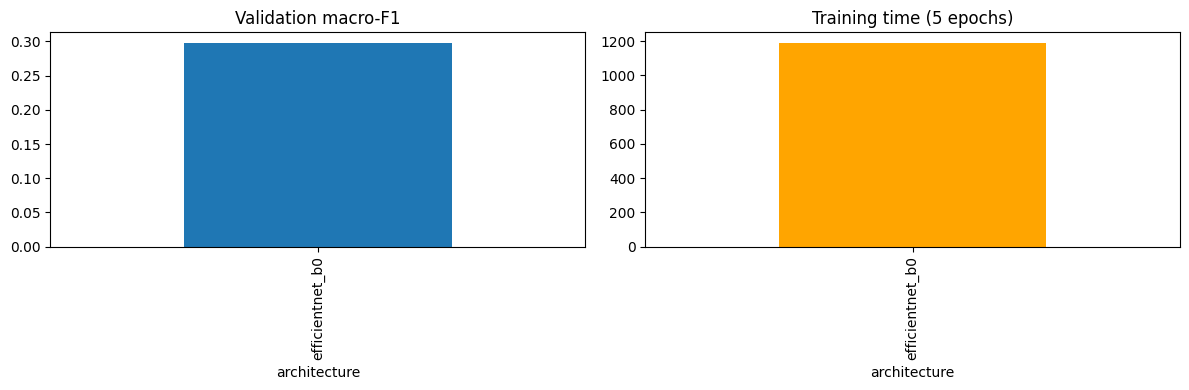


Best architecture by validation macro-F1: efficientnet_b0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison_df.set_index("architecture")["val_macro_f1"].plot(kind="bar", ax=axes[0], title="Validation macro-F1")
comparison_df.set_index("architecture")["seconds_for_5_epochs"].plot(kind="bar", ax=axes[1], title="Training time (5 epochs)", color="orange")
plt.tight_layout()
plt.show()

BEST_ARCH = comparison_df.iloc[0]["architecture"]
print(f"\nBest architecture by validation macro-F1: {BEST_ARCH}")


## 5. Full training run

Trains `BEST_ARCH` (chosen above) for more epochs, with early stopping on a validation
macro-F1 plateau. **Only one checkpoint path is ever written** (`artifacts/model.pth`),
and only when validation macro-F1 improves -- this removes the old notebook's ambiguity
where a *second*, unconditional `torch.save(...)` at the very end could silently overwrite
the best checkpoint with a possibly-overfit final-epoch model.


In [2]:
NUM_EPOCHS = 25
PATIENCE = 6  # stop if val macro-F1 hasn't improved in this many epochs

model = build_model(BEST_ARCH, num_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}
best_val_f1 = 0.0
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)
    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.3f} val_macro_f1={val_f1:.3f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        torch.save(model.state_dict(), ARTIFACTS_DIR / "model.pth")
        print(f"  \u2705 New best model saved (val_macro_f1={val_f1:.3f})")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"  Stopping early -- no improvement in {PATIENCE} epochs.")
            break

print(f"\nBest validation macro-F1 achieved: {best_val_f1:.3f}")


NameError: name 'build_model' is not defined

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train acc")
axes[1].plot(history["val_acc"], label="val acc")
axes[1].plot(history["val_f1"], label="val macro-F1")
axes[1].set_title("Accuracy / macro-F1")
axes[1].legend()
plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

## 6. Test-set evaluation

Loads the best checkpoint just saved (not whatever is left in memory) and reports:
- overall accuracy
- per-class precision/recall/F1 (`classification_report`)
- a confusion matrix, so misclassification *pairs* are visible directly, instead of
  inferring them from a single per-class accuracy number


In [ ]:
model = build_model(BEST_ARCH, num_classes).to(device)
model.load_state_dict(torch.load(ARTIFACTS_DIR / "model.pth", map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        all_preds.extend(outputs.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test accuracy: {test_acc*100:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


In [ ]:
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_normalized, cmap="Blues")
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=90)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (row-normalized)")
for i in range(num_classes):
    for j in range(num_classes):
        if cm_normalized[i, j] > 0.05:
            ax.text(j, i, f"{cm_normalized[i, j]:.2f}", ha="center", va="center",
                    color="white" if cm_normalized[i, j] > 0.5 else "black", fontsize=7)
plt.colorbar(im)
plt.tight_layout()
plt.show()


## 7. Save class names + model config

This is what removes the manual-sync bug in the previous version, where `ArtStyle.py`
hardcoded a `class_names` list that had to be kept in sync *by hand* with whatever
`ImageFolder` decided the order was. From now on, the app reads both of these files
instead of hardcoding anything.


In [ ]:
with open(ARTIFACTS_DIR / "class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)

with open(ARTIFACTS_DIR / "model_config.json", "w") as f:
    json.dump({
        "architecture": BEST_ARCH,
        "num_classes": num_classes,
        "image_size": IMG_SIZE,
        "test_accuracy": float(test_acc),
        "test_macro_f1": float(f1_score(all_labels, all_preds, average="macro")),
    }, f, indent=2)

print("Saved artifacts/class_names.json and artifacts/model_config.json")
print("artifacts/ now contains everything ArtStyle.py needs:")
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print(" -", p)
